# Random Recommender

In this notebook, we implement a non-personalized random recommender where scores are sampled from a normal distribution around rating means.

Metrics that we use the measure the performance of the recommender:
- Accuracy@K
- NDCG@K
- Diversity
- Personalisation
- Coverage


## 1) Environment setup and robust data loading

In [49]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [50]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for c in candidates:
        if (c / 'dataset').exists() and (c / 'EDA').exists():
            return c
    raise FileNotFoundError('Could not locate project root containing dataset/ and EDA/.')

PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_DIR = PROJECT_ROOT / 'dataset'
RESULTS_DIR = PROJECT_ROOT / 'data' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

WINE_PATH = DATASET_DIR / 'XWines_Full_100K_wines.csv'
RATING_PATH = DATASET_DIR / 'XWines_Full_21M_ratings.csv'

wines = pd.read_csv(
    WINE_PATH,
    usecols=['WineID', 'WineName', 'Type', 'Country', 'RegionName'],
    dtype={
        'WineID': 'int32',
        'WineName': 'string',
        'Type': 'category',
        'Country': 'category',
        'RegionName': 'string'
    }
)

ratings = pd.read_csv(
    RATING_PATH,
    usecols=['UserID', 'WineID', 'Rating'],
    dtype={'UserID': 'int32', 'WineID': 'int32', 'Rating': 'float32'}
)

wines = wines.drop_duplicates(subset='WineID').copy()
ratings = ratings.drop_duplicates(subset=['UserID', 'WineID']).copy()
ratings = ratings[ratings['WineID'].isin(wines['WineID'])].copy()

print('wines:', wines.shape)
print('ratings:', ratings.shape)
print('users:', ratings['UserID'].nunique())
print('items:', ratings['WineID'].nunique())


wines: (100646, 5)
ratings: (20590800, 3)
users: 1056079
items: 100646


## 2) EDA-guided snapshot

In this section, we will have again a look at our data distribution, the ratings and items popularity. We have presenteed the thorough analysis of this in the EDA notebook, and here we just mention it to have another look. 

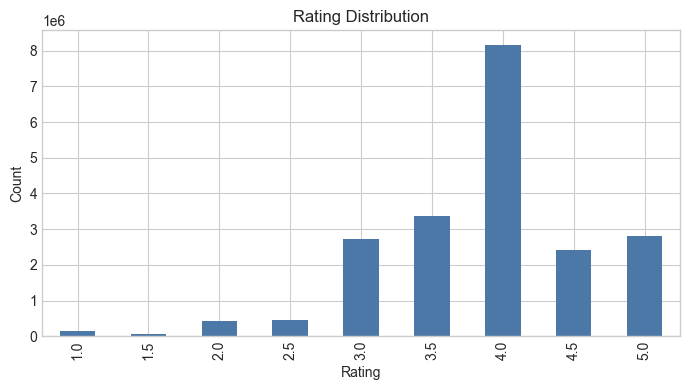

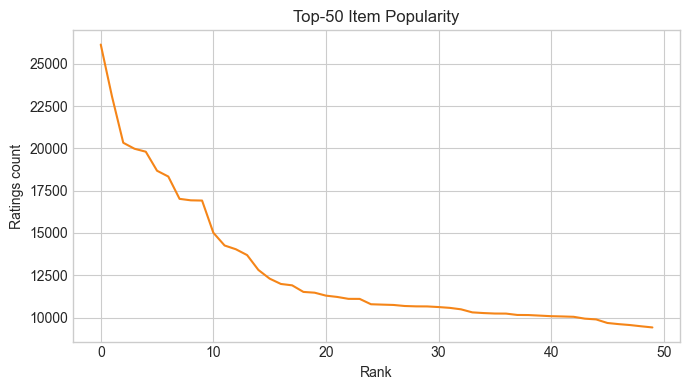

In [51]:
plt.figure(figsize=(7, 4))
ratings['Rating'].value_counts().sort_index().plot(kind='bar', color='#4C78A8')

plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
item_counts = ratings['WineID'].value_counts()

item_counts.head(50).reset_index(drop=True).plot(color='#F58518')

plt.title('Top-50 Item Popularity')
plt.xlabel('Rank')
plt.ylabel('Ratings count')

plt.tight_layout()
plt.show()


As we saw before, the rating dostribution is skewed to the right, and we see more posisitve ratings, with the average at aprx 4. 

The graph shows that a small number of items receive a very high number of ratings, while most items have much fewer ratings.

## 3) Positive Interactions and Train/Test Split


In this section, we first keeps only high ratings (4 and above) and remove users who have too few or too many interactions, so the data is more balanced. Then, we randomly selects up to 5000 users and split each user’s data into training and testing sets, while also assigning folds for cross-validation.

In [52]:
from pathlib import Path

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().resolve()
for c in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (c / 'data' / 'results' / 'shared_split').exists():
        PROJECT_ROOT = c
        break

SPLIT_DIR = PROJECT_ROOT / 'data' / 'results' / 'shared_split'

trainval_pos = pd.read_csv(
    SPLIT_DIR / 'train_pos.csv',
    dtype={'UserID': 'int32', 'WineID': 'int32', 'Rating': 'float32'}
)
test_pos = pd.read_csv(
    SPLIT_DIR / 'test_pos.csv',
    dtype={'UserID': 'int32', 'WineID': 'int32', 'Rating': 'float32'}
)

test_relevant = test_pos.groupby('UserID')['WineID'].apply(set).to_dict()
shared_users = sorted(test_pos['UserID'].unique())

print('Loaded shared split from:', SPLIT_DIR)
print('trainval:', trainval_pos.shape)
print('test:', test_pos.shape)
print('shared users:', len(shared_users))


Loaded shared split from: /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/shared_split
trainval: (56673, 3)
test: (16646, 3)
shared users: 5000


## 4) Metrics for evaluation

In order to evaluate the work that has been done, we will define he metrics below: 

- Accuracy@K
- NDCG@K
- Diversity@K
- Personalisation@10
- Coverage


In [53]:
def accuracy_at_k(relevant, recommended, k):
    rec_k = recommended[:k]
    if k == 0:
        return 0.0
    hits = sum(1 for x in rec_k if x in relevant)
    return hits / k


def dcg_at_k(relevant, recommended, k):
    score = 0.0
    for i, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            score += 1.0 / np.log2(i + 1)
    return score


def ndcg_at_k(relevant, recommended, k):
    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return 0.0
    ideal_dcg = sum(1.0 / np.log2(i + 1) for i in range(1, ideal_hits + 1))
    return dcg_at_k(relevant, recommended, k) / ideal_dcg


In [54]:
item_meta = wines.set_index('WineID')[['Type', 'Country']].copy()
item_meta['Type'] = item_meta['Type'].astype(str).str.lower().fillna('unknown')
item_meta['Country'] = item_meta['Country'].astype(str).str.lower().fillna('unknown')


def item_signature(wine_id):
    if wine_id not in item_meta.index:
        return {'unknown'}
    row = item_meta.loc[wine_id]
    return {f"type:{row['Type']}", f"country:{row['Country']}"}


item_signatures = {wid: item_signature(wid) for wid in item_meta.index}


def jaccard_distance(a, b):
    inter = len(a & b)
    union = len(a | b)
    if union == 0:
        return 0.0
    return 1.0 - (inter / union)


def intra_list_diversity(recommended):
    if len(recommended) < 2:
        return 0.0
    dists = []
    for i in range(len(recommended)):
        for j in range(i + 1, len(recommended)):
            a = item_signatures.get(recommended[i], {'unknown'})
            b = item_signatures.get(recommended[j], {'unknown'})
            dists.append(jaccard_distance(a, b))
    return float(np.mean(dists)) if dists else 0.0


def personalisation_at_k(recs_by_user, k=10, max_users=300, random_state=42):
    users = list(recs_by_user.keys())
    if len(users) < 2:
        return 0.0

    rng = np.random.default_rng(random_state)
    if len(users) > max_users:
        users = rng.choice(users, size=max_users, replace=False).tolist()

    sets = {u: set(recs_by_user[u][:k]) for u in users}

    sims = []
    for u1, u2 in itertools.combinations(users, 2):
        a, b = sets[u1], sets[u2]
        union = len(a | b)
        sim = (len(a & b) / union) if union > 0 else 0.0
        sims.append(sim)

    if not sims:
        return 0.0
    return float(1.0 - np.mean(sims))


The function below  evaluates how well the recommender system works by generating recommendations for each user and comparing them to the items they actually liked. It calculates metrics like accuracy, ranking quality (NDCG), diversity, and also measures overall coverage and personalization of the recommendations.

In [55]:
def evaluate_model(model, recommend_fn, eval_users, relevant_dict, ks=(5, 10, 20)):
    rows = []
    recs_by_user = {}
    max_k = max(ks)
    all_top10_items = []

    for user_id in eval_users:
        relevant = relevant_dict.get(user_id, set())
        if not relevant:
            continue

        recs = recommend_fn(model, user_id, top_k=max_k)
        if len(recs) == 0:
            continue

        recs_by_user[user_id] = recs
        all_top10_items.extend(recs[:10])

        row = {'UserID': user_id}
        for k in ks:
            row[f'Accuracy@{k}'] = accuracy_at_k(relevant, recs, k)
            row[f'NDCG@{k}'] = ndcg_at_k(relevant, recs, k)
            row[f'Diversity@{k}'] = intra_list_diversity(recs[:k])

        rows.append(row)

    eval_df = pd.DataFrame(rows)
    if eval_df.empty:
        return eval_df, {}, recs_by_user

    coverage = len(set(all_top10_items)) / len(model['all_items']) if len(model['all_items']) else 0.0
    pers = personalisation_at_k(recs_by_user, k=10, max_users=300, random_state=RANDOM_STATE)

    extra = {
        'Coverage': coverage,
        'Personalisation@10': pers
    }
    return eval_df, extra, recs_by_user


In [56]:
def plot_model_diagnostics(eval_df, recs_by_user, model_name, top_k=10):
    if eval_df.empty:
        print(f'No evaluation rows for {model_name}')
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    sns.histplot(eval_df[f'Accuracy@{top_k}'], bins=25, kde=True, ax=axes[0], color='#4C78A8')
    axes[0].set_title(f'{model_name} - Accuracy@{top_k}')

    sns.histplot(eval_df[f'NDCG@{top_k}'], bins=25, kde=True, ax=axes[1], color='#54A24B')
    axes[1].set_title(f'{model_name} - NDCG@{top_k}')

    all_items = []
    for _, recs in recs_by_user.items():
        all_items.extend(recs[:top_k])

    freq = pd.Series(all_items).value_counts() if all_items else pd.Series(dtype='int64')
    if freq.empty:
        axes[2].text(0.5, 0.5, 'No recs', ha='center', va='center')
    else:
        sns.histplot(freq.values, bins=30, kde=False, ax=axes[2], color='#F58518')
    axes[2].set_title(f'{model_name} - Coverage histogram')
    axes[2].set_xlabel('recommendation count per item')

    plt.tight_layout()
    plt.show()


## 5) Random recommender

For each unseen item we sample:
`score_i ~ N(mu_i, sigma_global)`

where `mu_i` is the item mean rating on train (fallback to global mean) and `sigma_global` is the standard deviation of ratings in the dataset.


This code builds a simple recommender model that learns the average rating of each item and the overall rating distribution from the training data. 

Then, for each user, it recommends unseen items by randomly sampling scores around these averages and selecting the top-ranked ones.

In [57]:
def fit_random_normal_model(train_df, all_items, seed=42):
    item_mean = train_df.groupby('WineID')['Rating'].mean()
    global_mean = float(train_df['Rating'].mean())
    global_std = float(train_df['Rating'].std(ddof=0))

    train_seen = train_df.groupby('UserID')['WineID'].apply(set).to_dict()
    all_items = np.array(sorted(all_items), dtype=np.int32)

    return {
        'item_mean': item_mean,
        'global_mean': global_mean,
        'global_std': max(global_std, 1e-3),
        'seed': seed,
        'train_seen': train_seen,
        'all_items': all_items,
    }


def recommend_random_normal(model, user_id, top_k=10):
    seen = model['train_seen'].get(user_id, set())
    candidates = [wid for wid in model['all_items'] if wid not in seen]
    if not candidates:
        return []

    means = model['item_mean'].reindex(candidates).fillna(model['global_mean']).to_numpy()
    sigma = model['global_std']

    rng = np.random.default_rng(model['seed'] + int(user_id))
    sampled_scores = rng.normal(loc=means, scale=sigma, size=len(candidates))

    order = np.argsort(sampled_scores)[::-1]
    return [int(candidates[i]) for i in order[:top_k]]


## 6) Final Evaluation on Held-out Test


In this section, we train the final random recommender on the training and validation data (since there is no parameter tuning), test it on the held-out test set, and then we calculate the average evaluation results. 

In the end, it displays the overall performance of the model.


In [58]:
final_model = fit_random_normal_model(
    trainval_pos,
    all_items=wines['WineID'].unique(),
    seed=RANDOM_STATE
)

random_eval_df, random_extra, random_recs_by_user = evaluate_model(
    final_model,
    recommend_random_normal,
    shared_users,
    test_relevant,
    ks=(5, 10, 20)
)

random_summary = random_eval_df.drop(columns='UserID').mean().to_dict()
random_summary.update(random_extra)
random_summary = pd.DataFrame([random_summary], index=['RandomNormal'])
display(random_summary)
print('Sampling sigma is fixed to global_std.')

,Accuracy@5,NDCG@5,Diversity@5,Accuracy@10,NDCG@10,Diversity@10,Accuracy@20,NDCG@20,Diversity@20,Coverage,Personalisation@10
RandomNormal,0.0,0.0,0.76272,0.00002,0.000026,0.763496,0.00004,0.000098,0.765735,0.061542,0.998543


Sampling sigma is fixed to global_std.


The accuracy and NDCG values are almost zero, which means the model is not good at recommending items that users actually like. This happens because the recommendations are generated using randomness, so even though item averages are considered, the model does not truly learn user preferences.

At the same time, the diversity scores are relatively high. This is because the model suggests many different items instead of repeating the same ones. Similarly, the personalisation score is very high, but this is a false friend. It does not mean the recommendations are actually good or tailored to the user. Instead, it only shows that different users are getting different random items, without considering recommendation quality.

The coverage is not very high, which means the model is not using a large portion of all available items. This can be partly explained by the earlier filtering of users, which reduces the variety of interactions in the data. However, the main reason is the nature of the random recommender itself. Since it samples scores around item averages, it tends to repeatedly recommend a subset of items rather than exploring the full item space.


### Qualitative examples

Here we would like to show recommendation lists for 3 different users to showcase different products returned by the random recommender.


In [59]:
example_users = sorted(random_recs_by_user.keys())[:3]
print('Example users:', example_users)

for user_id in example_users:
    recs = recommend_random_normal(final_model, user_id, top_k=10)
    print(f'\nUser {user_id}')
    display(
        wines[wines['WineID'].isin(recs)][['WineID', 'WineName', 'Type', 'Country']]
        .set_index('WineID')
        .loc[recs]
    )


Example users: [np.int32(1000404), np.int32(1001240), np.int32(1001312)]

User 1000404


,WineName,Type,Country
WineID,,,
114096,Les Deux Aristos Cabernet-Syrah,Red,France
112554,Puligny-Montrachet,White,France
144687,Amarone Stella,Red,Italy
136982,Prosecco,Sparkling,Italy
120932,Bélemnites Pouilly-Fuissé,White,France
123127,Morey-Saint-Denis 1er Cru 'Aux Cheseaux',Red,France
138650,Coste di Rose Barolo,Red,Italy
113882,Sauvignon Blanc,White,France
118325,Meix Chavaux Meursault,White,France



User 1001240


,WineName,Type,Country
WineID,,,
157683,No. 12 Albariño,White,Spain
175937,Cabernet-Merlot,Red,Australia
184715,Merlot,Red,United States
138088,Tirrenico,Red,Italy
142039,Barbera d'Alba Scarrone Vigna Vecchia,Red,Italy
122084,Chassagne-Montrachet Blanc,White,France
145660,Recioto di Soave Classico,Dessert,Italy
120124,Maranges Premier Cru,Red,France
141125,Bigarò Rosé,Rosé,Italy



User 1001312


,WineName,Type,Country
WineID,,,
179111,Eight Years In The Desert,Red,United States
113564,Châteauneuf-du-Pape,Red,France
112587,Saint-Émilion Grand Cru (Grand Cru Classé),Red,France
163064,Tocornal Chardonnay,White,Chile
106624,Das Ist Riesling,White,Germany
179799,Tapestry Reserve Red Blend,Red,United States
171769,Syrah (Clonal Selection),Red,South Africa
137778,Primitivo Salento,Red,Italy
107938,Sommersemester,White,Germany


As we can see, the recommendations for the three users are all different, which shows that the model produces varied outputs for each user. However, this difference comes from randomness rather than true personalization, since the model does not actually learn individual user preferences.


## 7) Final Output Table


In [60]:
ordered_cols = [
    'Accuracy@5', 'Accuracy@10', 'Accuracy@20',
    'NDCG@5', 'NDCG@10', 'NDCG@20',
    'Diversity@5', 'Diversity@10', 'Diversity@20',
    'Personalisation@10', 'Coverage'
]
available_cols = [c for c in ordered_cols if c in random_summary.columns]
random_summary = random_summary[available_cols]
display(random_summary)


,Accuracy@5,Accuracy@10,Accuracy@20,NDCG@5,NDCG@10,NDCG@20,Diversity@5,Diversity@10,Diversity@20,Personalisation@10,Coverage
RandomNormal,0.0,0.00002,0.00004,0.0,0.000026,0.000098,0.76272,0.763496,0.765735,0.998543,0.061542


The random recommender achieves almost zero accuracy and NDCG, which shows it is not effective at recommending relevant items to users. However, it has high diversity and personalisation scores, but these are misleading since they come from randomness rather than true understanding of user preferences.

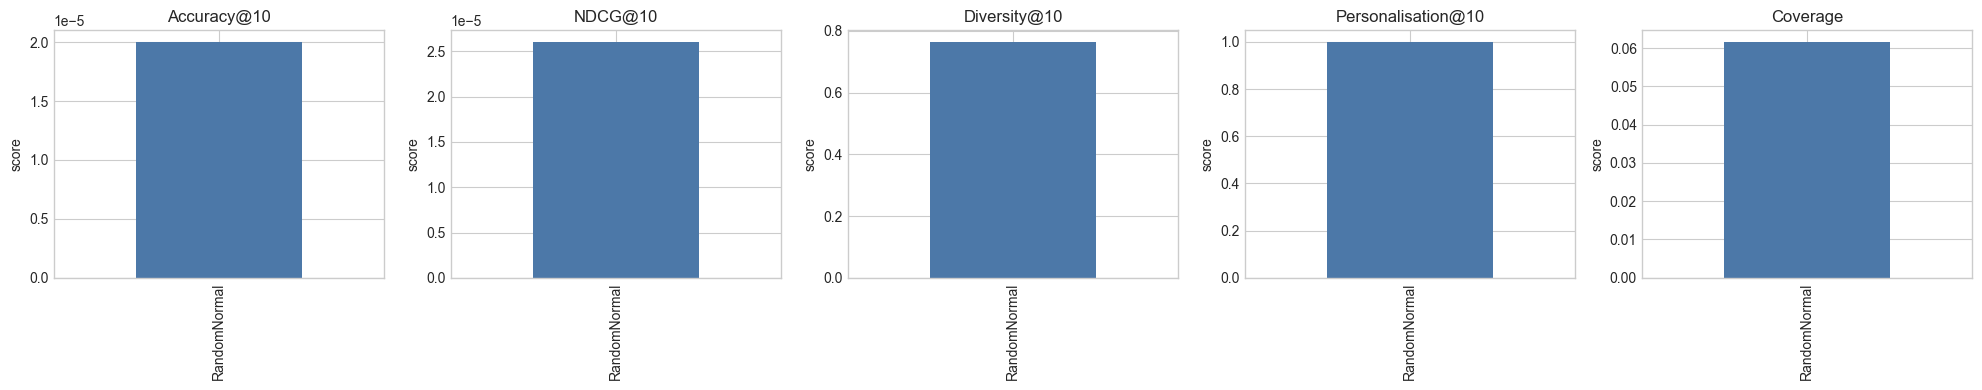

In [61]:
plot_cols = ['Accuracy@10', 'NDCG@10', 'Diversity@10', 'Personalisation@10', 'Coverage']
avail = [c for c in plot_cols if c in random_summary.columns]

if avail:
    fig, axes = plt.subplots(1, len(avail), figsize=(4 * len(avail), 4))
    if len(avail) == 1:
        axes = [axes]
    for ax, col in zip(axes, avail):
        random_summary[col].plot(kind='bar', ax=ax, color='#4C78A8')
        ax.set_title(col)
        ax.set_ylabel('score')
    plt.tight_layout()
    plt.show()


In [62]:
metrics_path = RESULTS_DIR / 'nonpers_random_metrics.csv'
summary_path = RESULTS_DIR / 'nonpers_random_summary.csv'
random_eval_df.to_csv(metrics_path, index=False)
random_summary.to_csv(summary_path)

print('Saved:')
print('-', metrics_path)
print('-', summary_path)


Saved:
- /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/nonpers_random_metrics.csv
- /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/nonpers_random_summary.csv


# 8) Conclusion

Overall, this model serves as a baseline and highlights that while randomness can produce varied recommendations, it does not result in meaningful or useful recommendations for users.

# 9) Save the models

In [63]:
from pathlib import Path
import pandas as pd

ARMS_DIR = Path("../bandits/saved_arms")
ARMS_DIR.mkdir(parents=True, exist_ok=True)

def export_arm_recs(recommend_fn, users, out_csv, top_k=100):
    rows = []
    for uid in users:
        recs = recommend_fn(int(uid), top_k=top_k)
        for r, wid in enumerate(recs, start=1):
            rows.append({"UserID": int(uid), "rank": int(r), "WineID": int(wid)})
    out_df = pd.DataFrame(rows)
    out_df.to_csv(out_csv, index=False)
    print(f"Saved {len(out_df):,} rows -> {out_csv}")


In [64]:
export_arm_recs(
    recommend_fn=lambda uid, top_k=100: recommend_random_normal(final_model, uid, top_k=top_k),
    users=eval_users,
    out_csv=ARMS_DIR / "random_normal_recs.csv",
    top_k=100
)


Saved 500,000 rows -> ../bandits/saved_arms/random_normal_recs.csv
